In [2]:
#Install and import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import json

from tqdm import tqdm
from textblob import TextBlob
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [3]:
# File path
file_path = "/content/amazon_raw_flat.csv"

# Load CSV into DataFrame
df = pd.read_csv(file_path)

# Basic checks
print("Shape:", df.shape)
df.head()

Shape: (13070, 168)


/tmp/ipykernel_4127/4116054303.py:5: DtypeWarning: Columns (29,42,43,46,62,63,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,type,id,url,twitterUrl,text,fullText,source,retweetCount,replyCount,likeCount,...,quote.place.full_name,quote.place.id,quote.place.name,quote.place.place_type,quote.place.url,quote.author.withheldInCountries,quote.author.affiliatesHighlightedLabel.label.longDescription.entities,quote.author.affiliatesHighlightedLabel.label.longDescription.text,quote.url,quote.twitterUrl
0,tweet,2008327517346685380,https://x.com/PriceErrors_/status/200832751734...,https://twitter.com/PriceErrors_/status/200832...,Road Comforts Car Seat Covers\n\nNow $28.xx\nR...,Road Comforts Car Seat Covers\n\nNow $28.xx\nR...,Twitter Web App,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,tweet,2008327414825243105,https://x.com/dipperid/status/2008327414825243105,https://twitter.com/dipperid/status/2008327414...,Destiny is on a show called Party Lines' on Am...,Destiny is on a show called Party Lines' on Am...,Twitter Web App,14,26,500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,tweet,2008327358852239685,https://x.com/lberrelez32/status/2008327358852...,https://twitter.com/lberrelez32/status/2008327...,Thank you @SenateTim for the generous donation...,Thank you @SenateTim for the generous donation...,Twitter for iPhone,1,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,tweet,2008327351856156805,https://x.com/PCPartsDrop/status/2008327351856...,https://twitter.com/PCPartsDrop/status/2008327...,"Amazon Open Box [$202.65, $97.34 (32%) off, Ac...","Amazon Open Box [$202.65, $97.34 (32%) off, Ac...",Twitter Web App,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,tweet,2008327284151681107,https://x.com/c__honey/status/2008327284151681107,https://twitter.com/c__honey/status/2008327284...,Finds something on TikTok.. goes straight to A...,Finds something on TikTok.. goes straight to A...,Twitter for iPhone,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print(df.columns.tolist())

['type', 'id', 'url', 'twitterUrl', 'text', 'fullText', 'source', 'retweetCount', 'replyCount', 'likeCount', 'quoteCount', 'viewCount', 'createdAt', 'lang', 'bookmarkCount', 'isReply', 'conversationId', 'possiblySensitive', 'isPinned', 'isRetweet', 'isQuote', 'media', 'isConversationControlled', 'author.type', 'author.userName', 'author.url', 'author.twitterUrl', 'author.id', 'author.name', 'author.isBlueVerified', 'author.profilePicture', 'author.coverPicture', 'author.description', 'author.followers', 'author.following', 'author.status', 'author.canDm', 'author.canMediaTag', 'author.createdAt', 'author.entities.url.urls', 'author.fastFollowersCount', 'author.favouritesCount', 'author.hasCustomTimelines', 'author.isTranslator', 'author.mediaCount', 'author.statusesCount', 'author.possiblySensitive', 'author.pinnedTweetIds', 'extendedEntities.media', 'entities.hashtags', 'entities.media', 'entities.symbols', 'entities.timestamps', 'entities.urls', 'entities.user_mentions', 'author.loca

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13070 entries, 0 to 13069
Columns: 168 entries, type to quote.twitterUrl
dtypes: bool(6), float64(30), int64(7), object(125)
memory usage: 16.2+ MB


In [6]:
#selecting only the needed and meaningful columns

# Select only relevant columns based on your dataset
selected_columns = [
    'id',
    'url',
    'fullText',
    'text',
    'createdAt',
    'lang',
    'retweetCount',
    'replyCount',
    'likeCount',
    'quoteCount',
    'viewCount',
    'author.userName',
    'author.followers',
    'entities.hashtags'
]

# Keep only columns that actually exist
existing_columns = [col for col in selected_columns if col in df.columns]

df_selected = df[existing_columns].copy()

print("Selected shape:", df_selected.shape)
df_selected.head()

Selected shape: (13070, 14)


,id,url,fullText,text,createdAt,lang,retweetCount,replyCount,likeCount,quoteCount,viewCount,author.userName,author.followers,entities.hashtags
0,2008327517346685380,https://x.com/PriceErrors_/status/200832751734...,Road Comforts Car Seat Covers\n\nNow $28.xx\nR...,Road Comforts Car Seat Covers\n\nNow $28.xx\nR...,Mon Jan 05 23:59:27 +0000 2026,en,0,0,0,0,107.0,PriceErrors_,7964.0,[]
1,2008327414825243105,https://x.com/dipperid/status/2008327414825243105,Destiny is on a show called Party Lines' on Am...,Destiny is on a show called Party Lines' on Am...,Mon Jan 05 23:59:03 +0000 2026,en,14,26,500,5,46767.0,dipperid,912.0,[]
2,2008327358852239685,https://x.com/lberrelez32/status/2008327358852...,Thank you @SenateTim for the generous donation...,Thank you @SenateTim for the generous donation...,Mon Jan 05 23:58:49 +0000 2026,en,1,0,2,0,53.0,lberrelez32,10803.0,[]
3,2008327351856156805,https://x.com/PCPartsDrop/status/2008327351856...,"Amazon Open Box [$202.65, $97.34 (32%) off, Ac...","Amazon Open Box [$202.65, $97.34 (32%) off, Ac...",Mon Jan 05 23:58:48 +0000 2026,en,0,0,0,0,95.0,PCPartsDrop,1458.0,"[{'indices': [263, 266], 'text': 'ad'}]"
4,2008327284151681107,https://x.com/c__honey/status/2008327284151681107,Finds something on TikTok.. goes straight to A...,Finds something on TikTok.. goes straight to A...,Mon Jan 05 23:58:32 +0000 2026,en,0,0,0,0,22.0,c__honey,627.0,[]


In [7]:
#Create main text column

# Create unified text column
df_selected['tweet_text'] = df_selected['fullText'].fillna(df_selected['text'])

# Convert to string (important for NLP)
df_selected['tweet_text'] = df_selected['tweet_text'].astype(str)

# Check
df_selected[['tweet_text']].head()

,tweet_text
0,Road Comforts Car Seat Covers\n\nNow $28.xx\nR...
1,Destiny is on a show called Party Lines' on Am...
2,Thank you @SenateTim for the generous donation...
3,"Amazon Open Box [$202.65, $97.34 (32%) off, Ac..."
4,Finds something on TikTok.. goes straight to A...


In [8]:
#Quick sanity checks

# Check missing text
print("Missing text:", df_selected['tweet_text'].isna().sum())

# Check duplicates
print("Duplicate tweets:", df_selected.duplicated(subset=['tweet_text']).sum())

# Language distribution
print(df_selected['lang'].value_counts().head())

Missing text: 0
Duplicate tweets: 81
lang
en    13070
Name: count, dtype: int64


In [9]:
#filter only English tweets

df_selected = df_selected[df_selected['lang'] == 'en']

print("After English filter:", df_selected.shape)

After English filter: (13070, 15)


In [10]:
# Remove duplicates and finalize base dataset

# Remove duplicate tweets
df_clean = df_selected.drop_duplicates(subset=['tweet_text']).copy()

print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (12989, 15)


In [11]:
# Clean tweet text for NLP

import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)      # remove URLs
    text = re.sub(r"@\w+", "", text)               # remove mentions
    text = re.sub(r"#", "", text)                  # remove hashtag symbol
    text = re.sub(r"[^a-z\s]", "", text)           # keep only letters
    text = re.sub(r"\s+", " ", text).strip()       # remove extra spaces

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

df_clean['clean_text'] = df_clean['tweet_text'].apply(clean_text)

df_clean[['tweet_text', 'clean_text']].head()

,tweet_text,clean_text
0,Road Comforts Car Seat Covers\n\nNow $28.xx\nR...,road comforts car seat covers xx reg xx clip c...
1,Destiny is on a show called Party Lines' on Am...,destiny show called party lines amazon prime v...
2,Thank you @SenateTim for the generous donation...,thank generous donation much needed pencils un...
3,"Amazon Open Box [$202.65, $97.34 (32%) off, Ac...",amazon open box acceptable condition asus rog ...
4,Finds something on TikTok.. goes straight to A...,finds something tiktok goes straight amazon ge...


In [12]:
# Create time-based features

df_clean['createdAt'] = pd.to_datetime(df_clean['createdAt'], errors='coerce')

df_clean['date'] = df_clean['createdAt'].dt.date
df_clean['hour'] = df_clean['createdAt'].dt.hour
df_clean['day_of_week'] = df_clean['createdAt'].dt.day_name()

df_clean.head()

/tmp/ipykernel_4127/2145281201.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['createdAt'] = pd.to_datetime(df_clean['createdAt'], errors='coerce')


,id,url,fullText,text,createdAt,lang,retweetCount,replyCount,likeCount,quoteCount,viewCount,author.userName,author.followers,entities.hashtags,tweet_text,clean_text,date,hour,day_of_week
0,2008327517346685380,https://x.com/PriceErrors_/status/200832751734...,Road Comforts Car Seat Covers\n\nNow $28.xx\nR...,Road Comforts Car Seat Covers\n\nNow $28.xx\nR...,2026-01-05 23:59:27+00:00,en,0,0,0,0,107.0,PriceErrors_,7964.0,[],Road Comforts Car Seat Covers\n\nNow $28.xx\nR...,road comforts car seat covers xx reg xx clip c...,2026-01-05,23,Monday
1,2008327414825243105,https://x.com/dipperid/status/2008327414825243105,Destiny is on a show called Party Lines' on Am...,Destiny is on a show called Party Lines' on Am...,2026-01-05 23:59:03+00:00,en,14,26,500,5,46767.0,dipperid,912.0,[],Destiny is on a show called Party Lines' on Am...,destiny show called party lines amazon prime v...,2026-01-05,23,Monday
2,2008327358852239685,https://x.com/lberrelez32/status/2008327358852...,Thank you @SenateTim for the generous donation...,Thank you @SenateTim for the generous donation...,2026-01-05 23:58:49+00:00,en,1,0,2,0,53.0,lberrelez32,10803.0,[],Thank you @SenateTim for the generous donation...,thank generous donation much needed pencils un...,2026-01-05,23,Monday
3,2008327351856156805,https://x.com/PCPartsDrop/status/2008327351856...,"Amazon Open Box [$202.65, $97.34 (32%) off, Ac...","Amazon Open Box [$202.65, $97.34 (32%) off, Ac...",2026-01-05 23:58:48+00:00,en,0,0,0,0,95.0,PCPartsDrop,1458.0,"[{'indices': [263, 266], 'text': 'ad'}]","Amazon Open Box [$202.65, $97.34 (32%) off, Ac...",amazon open box acceptable condition asus rog ...,2026-01-05,23,Monday
4,2008327284151681107,https://x.com/c__honey/status/2008327284151681107,Finds something on TikTok.. goes straight to A...,Finds something on TikTok.. goes straight to A...,2026-01-05 23:58:32+00:00,en,0,0,0,0,22.0,c__honey,627.0,[],Finds something on TikTok.. goes straight to A...,finds something tiktok goes straight amazon ge...,2026-01-05,23,Monday


In [13]:
# from textblob import TextBlob

def get_sentiment_score(text):
    return TextBlob(text).sentiment.polarity

def get_sentiment_label(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df_clean['sentiment_score'] = df_clean['clean_text'].apply(get_sentiment_score)
df_clean['sentiment_label'] = df_clean['sentiment_score'].apply(get_sentiment_label)

df_clean[['clean_text', 'sentiment_score', 'sentiment_label']].head()


,clean_text,sentiment_score,sentiment_label
0,road comforts car seat covers xx reg xx clip c...,0.0,Neutral
1,destiny show called party lines amazon prime v...,0.0,Neutral
2,thank generous donation much needed pencils un...,0.1,Positive
3,amazon open box acceptable condition asus rog ...,0.0,Neutral
4,finds something tiktok goes straight amazon ge...,0.5,Positive


In [14]:
print(df_clean['sentiment_label'].value_counts())

sentiment_label
Positive    6102
Neutral     5189
Negative    1698
Name: count, dtype: int64


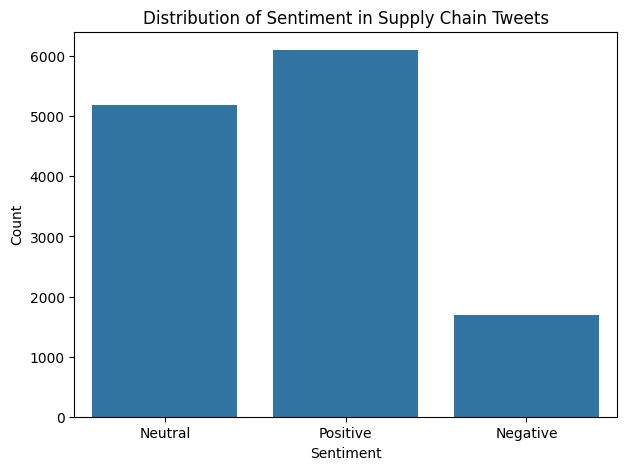

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.countplot(data=df_clean, x='sentiment_label')
plt.title("Distribution of Sentiment in Supply Chain Tweets")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [16]:
# Engagement vs sentiment

engagement_cols = ['retweetCount', 'replyCount', 'likeCount', 'quoteCount', 'viewCount']

for col in engagement_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

engagement_by_sentiment = df_clean.groupby('sentiment_label')[engagement_cols].mean()

engagement_by_sentiment

,retweetCount,replyCount,likeCount,quoteCount,viewCount
sentiment_label,,,,,
Negative,6.267373,1.898704,30.378681,0.478210,3643.719621
Neutral,6.105415,1.732897,38.640971,0.441318,3972.631251
Positive,6.331695,1.703540,32.208620,0.395444,2812.678855


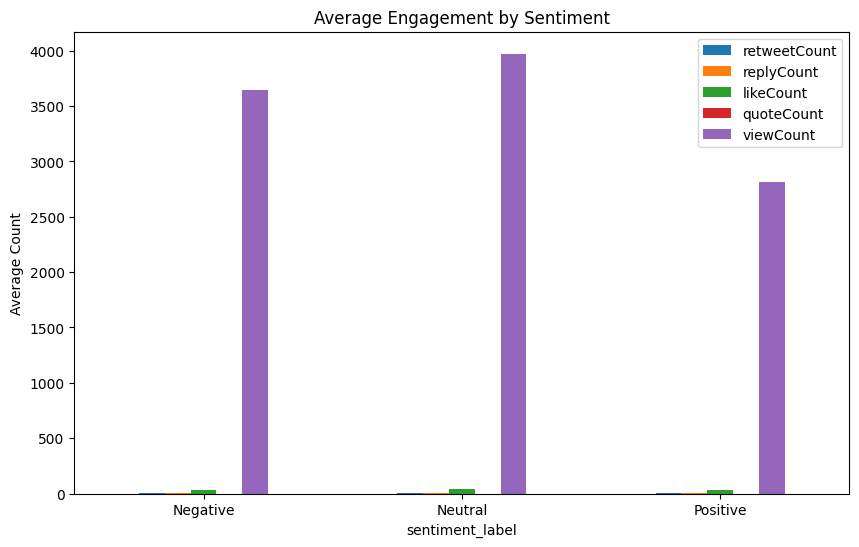

In [17]:
engagement_by_sentiment.plot(kind='bar', figsize=(10,6))
plt.title("Average Engagement by Sentiment")
plt.ylabel("Average Count")
plt.xticks(rotation=0)
plt.show()

In [18]:
# Define operational themes

theme_keywords = {
    "Delivery Delay": [
        "delay", "late", "delayed", "waiting", "took long",
        "not delivered", "delivery time", "arrive", "arrival"
    ],
    "Fulfillment Issue": [
        "missing", "wrong item", "damaged", "broken",
        "cancelled", "canceled", "refund", "return"
    ],
    "Last Mile Issue": [
        "driver", "courier", "delivery person",
        "doorstep", "address issue"
    ],
    "Customer Service": [
        "support", "customer service", "help",
        "no response", "call", "chat", "helpline"
    ],
    "Tracking Issue": [
        "tracking", "no update", "status",
        "not updated", "location", "where is my order"
    ]
}

In [19]:
# Assign themes to each tweet

def assign_single_theme(text):
    for theme, keywords in theme_keywords.items():
        for keyword in keywords:
            if keyword in text:
                return theme
    return "Other"

df_clean['theme'] = df_clean['clean_text'].apply(assign_single_theme)

In [20]:
theme_counts = df_clean['theme'].value_counts()
print(theme_counts)

theme
Other                11270
Customer Service       740
Delivery Delay         474
Fulfillment Issue      328
Last Mile Issue        124
Tracking Issue          53
Name: count, dtype: int64


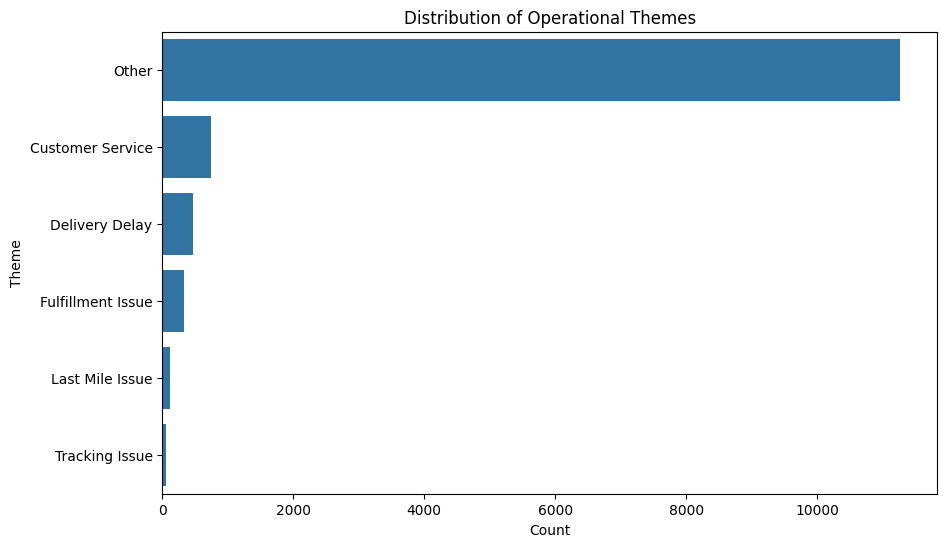

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, y='theme', order=theme_counts.index)
plt.title("Distribution of Operational Themes")
plt.xlabel("Count")
plt.ylabel("Theme")
plt.show()

In [22]:
df_clean[df_clean['theme'] == "Other"]['tweet_text'].sample(20, random_state=42)

,tweet_text
11534,New Amazon Coupons for October 19 – Fresh Deal...
2914,Mother throws Amazon Alexa device out of house...
4555,https://t.co/R6QuPaX3OA\nAmazon deals with ama...
5845,Survival in the Amazon: A woman recounts a bru...
7411,PS5 Slim is only $379.99 at Woot from Amazon: ...
11560,"Apple Watch Series 10 [GPS + Cellular, 42mm] -..."
8280,Know what? Never mind. EDC your Turkshit gun. ...
10708,"In the Old West, sometimes blood was the only ..."
11531,Amazon Essentials Women’s Long-Sleeve Crewneck...
747,"It’s cold outside, which makes it a great time..."


In [23]:
df_clean[df_clean['theme'] == "Other"][['tweet_text', 'clean_text']].sample(20, random_state=42)

,tweet_text,clean_text
11534,New Amazon Coupons for October 19 – Fresh Deal...,new amazon coupons october fresh deals need cl...
2914,Mother throws Amazon Alexa device out of house...,mother throws amazon alexa device house asked ...
4555,https://t.co/R6QuPaX3OA\nAmazon deals with ama...,amazon deals amazing offers
5845,Survival in the Amazon: A woman recounts a bru...,survival amazon woman recounts brutal attack l...
7411,PS5 Slim is only $379.99 at Woot from Amazon: ...,ps slim woot amazon ad free shipping prime goe...
11560,"Apple Watch Series 10 [GPS + Cellular, 42mm] -...",apple watch series gps cellular mm silver alum...
8280,Know what? Never mind. EDC your Turkshit gun. ...,know never mind edc turkshit gun fuck tourniqu...
10708,"In the Old West, sometimes blood was the only ...",old west sometimes blood thing could set man f...
11531,Amazon Essentials Women’s Long-Sleeve Crewneck...,amazon essentials womens longsleeve crewneck s...
747,"It’s cold outside, which makes it a great time...",cold outside makes great time get lost new boo...


In [24]:
from collections import Counter

other_text = " ".join(df_clean[df_clean['theme'] == "Other"]['clean_text'])
word_counts = Counter(other_text.split())

common_words = pd.DataFrame(word_counts.most_common(30), columns=['word', 'count'])
common_words

,word,count
0,amazon,10213
1,ad,1712
2,amp,1046
3,book,864
4,price,815
5,music,810
6,via,751
7,deal,706
8,new,677
9,one,656


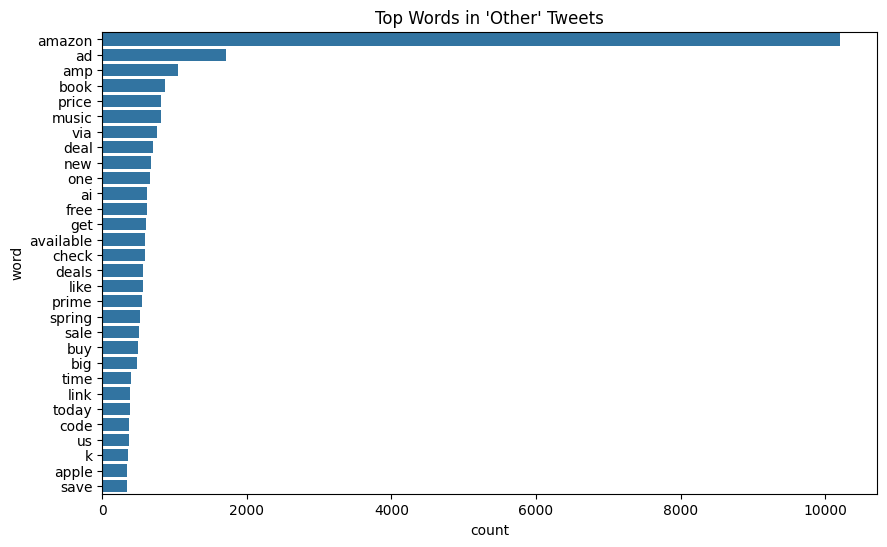

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=common_words, x='count', y='word')
plt.title("Top Words in 'Other' Tweets")
plt.show()

In [26]:
df_clean[df_clean['theme'] == "Other"][
    df_clean['clean_text'].str.contains("delivery|delay|refund|support|tracking", case=False, na=False)
][['tweet_text']].sample(20)

/tmp/ipykernel_4127/3411876860.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean[df_clean['theme'] == "Other"][


,tweet_text
12623,Are you looking for this epic cinematic book t...
1059,NEW Amazon LEGO Deal - $89.38 (10% OFF)\nCity ...
7814,📢 You can pay with your $SHIB on refillarena! ...
12618,Are you looking for this epic cinematic book t...
10465,This guy built a mock ‘Amazon delivery missile...
1028,Pokopia \n\nWalmart: out of stock \nBest Buy: ...
4225,Amazon Delivery system has crumbled down in ou...
545,Even Amazon is enshittifying.\n\n&gt; Find pro...
10369,"@USPS: Welp, we tried to deliver your @Amazon..."
5095,Amazon introduces one-hour and three-hour same...


In [27]:


df_clean['text_length'] = df_clean['clean_text'].apply(lambda x: len(x.split()))

df_clean[df_clean['theme'] == "Other"]['text_length'].describe()

,text_length
count,11270.000000
mean,16.775599
std,7.870781
min,0.000000
25%,10.000000
50%,17.000000
75%,24.000000
max,47.000000


In [28]:
# Remove promotional / irrelevant tweets

promo_keywords = [
    "deal", "sale", "buy", "price", "free", "offer",
    "link", "check", "available", "today", "ad", "promo"
]

def is_promo(text):
    for word in promo_keywords:
        if word in text:
            return True
    return False

df_clean['is_promo'] = df_clean['clean_text'].apply(is_promo)

In [29]:
# Remove promo tweets

df_filtered = df_clean[df_clean['is_promo'] == False].copy()

print("Before filtering:", df_clean.shape)
print("After filtering:", df_filtered.shape)

Before filtering: (12989, 24)
After filtering: (5031, 24)


In [30]:
df_filtered['theme'] = df_filtered['clean_text'].apply(assign_single_theme)

print(df_filtered['theme'].value_counts())

theme
Other                4202
Customer Service      344
Delivery Delay        223
Fulfillment Issue     163
Last Mile Issue        73
Tracking Issue         26
Name: count, dtype: int64


In [31]:
df_theme = df_filtered[df_filtered['theme'] != "Other"].copy()

print(df_theme['theme'].value_counts())

theme
Customer Service     344
Delivery Delay       223
Fulfillment Issue    163
Last Mile Issue       73
Tracking Issue        26
Name: count, dtype: int64


In [32]:
sentiment_theme_table = pd.crosstab(
    df_theme['theme'],
    df_theme['sentiment_label'],
    normalize='index'
) * 100

sentiment_theme_table.round(2)

sentiment_label,Negative,Neutral,Positive
theme,,,
Customer Service,19.77,40.41,39.83
Delivery Delay,22.42,30.49,47.09
Fulfillment Issue,38.65,31.90,29.45
Last Mile Issue,31.51,46.58,21.92
Tracking Issue,30.77,34.62,34.62


In [33]:
#Prepare modelling dataset

# Features and labels
X = df_theme['clean_text']
y = df_theme['sentiment_label']

print("Dataset size:", X.shape)
print(y.value_counts())

Dataset size: (829,)
sentiment_label
Positive    315
Neutral     302
Negative    212
Name: count, dtype: int64


In [34]:
# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (663,)
Test size: (166,)


In [35]:
# TF-IDF feature engineering

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),   # unigrams + bigrams
    min_df=3,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (663, 1194)
TF-IDF test shape: (166, 1194)


In [36]:
# Model 1 — Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')

lr_model.fit(X_train_tfidf, y_train)

lr_preds = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print("Logistic Regression F1 Score:", f1_score(y_test, lr_preds, average='weighted'))

print(classification_report(y_test, lr_preds))

Logistic Regression Accuracy: 0.572289156626506
Logistic Regression F1 Score: 0.5743932085076549
              precision    recall  f1-score   support

    Negative       0.49      0.60      0.54        42
     Neutral       0.54      0.52      0.53        61
    Positive       0.68      0.60      0.64        63

    accuracy                           0.57       166
   macro avg       0.57      0.57      0.57       166
weighted avg       0.58      0.57      0.57       166



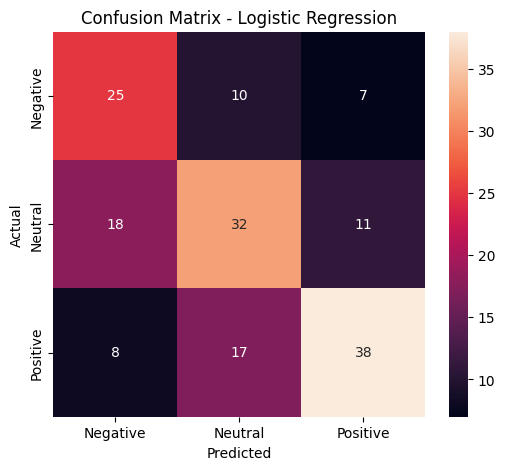

In [37]:
# Confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_preds, labels=lr_model.classes_)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=lr_model.classes_,
    yticklabels=lr_model.classes_
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
# Model 2 — Naive Bayes

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_preds = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("Naive Bayes F1 Score:", f1_score(y_test, nb_preds, average='weighted'))

print(classification_report(y_test, nb_preds))

Naive Bayes Accuracy: 0.6024096385542169
Naive Bayes F1 Score: 0.597564094303995
              precision    recall  f1-score   support

    Negative       0.71      0.40      0.52        42
     Neutral       0.53      0.66      0.59        61
    Positive       0.64      0.68      0.66        63

    accuracy                           0.60       166
   macro avg       0.63      0.58      0.59       166
weighted avg       0.62      0.60      0.60       166



In [39]:
# Compare models

import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, nb_preds)
    ],
    "Weighted F1 Score": [
        f1_score(y_test, lr_preds, average='weighted'),
        f1_score(y_test, nb_preds, average='weighted')
    ]
})

results

,Model,Accuracy,Weighted F1 Score
0,Logistic Regression,0.572289,0.574393
1,Naive Bayes,0.602410,0.597564


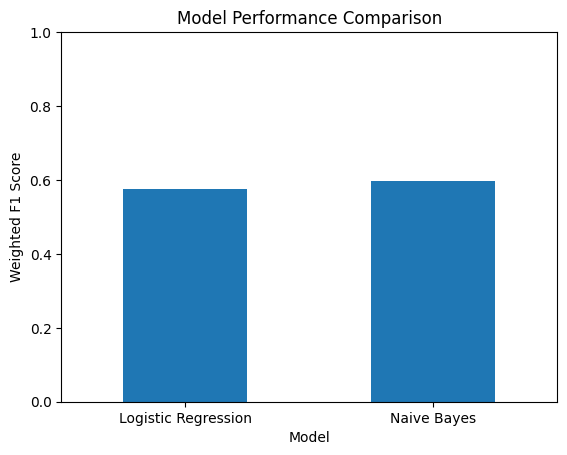

In [40]:
# Plot model comparison

results.plot(x="Model", y="Weighted F1 Score", kind="bar", legend=False)
plt.title("Model Performance Comparison")
plt.ylabel("Weighted F1 Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()